#### 6) Required System 1: Baseline RAG Pipeline
Implement a baseline RAG pipeline as follows:
1. Mine text from the document content (e.g. using any pdf processing library)

Deciding on a pdf processing library I checked a guys tips here: \
https://onlyoneaman.medium.com/i-tested-7-python-pdf-extractors-so-you-dont-have-to-2025-edition-c88013922257

- marker-pdf (11.3s): Perfect structure preservation, ideal for high-quality conversions, long time though
- pymupdf4llm (0.12s): Excellent markdown output, great balance of speed and quality
- unstructured (1.29s): Clean semantic chunks, perfect for RAG workflows
- textract (0.21s): Fast with OCR capabilities, minor formatting variations
- pypdfium2 (0.003s): Blazing speed, clean basic text, no structure
- pypdf (0.024s): Reliable extraction, occasional spacing artifacts
- pdfplumber (0.10s): Good for tables, text extraction needs configuration

For RAG systems he recommended `unstructured`.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from typing import List, Dict, Any
from unstructured.partition.auto import partition

In [22]:
print(os.getcwd())
path = "../data/train/pdfs_train/0b85477387a9d0cc33fca0f4becaa0e5.pdf"
os.path.exists(path)

c:\Users\kiran\Documents\_UIS\sem8\DAT560_GenerativAI_10\DAT560project\src\notebooks


True

In [23]:
# pip install "unstructured[all-docs]"
blocks = partition(filename=path)

In [24]:
for block in blocks:
    print(f"{block.category}: {block.text}")

Header: NMR&D News
Title: Volume IV, Issue 12
Title: In this issue…
NarrativeText: 2 CO‟s Messages 3 Building Afghan Medical Capacity 4 USNS Mercy Pacific Partnership 5 DoD Bone Marrow Donor Program 6 ID Joint Planning Group 7 Capacity Building in Liberia 8 Kazakh Scientists Train at NMRC 9 Patient Condition Occurrence Tool 10 Combat Casualty Research Team 11 Accelerating Technology Transfer 12 NMRC Hosts Dining Out 13 Villasante Speaks at Notre Dame 14 Keane-Myers Speaks at Hopkins 14 Cub Scouts Learn Flag Etiquette 15 NMRC High School Outreach NMRC Officers Teach Science 15 2012 Combined Federal Campaign 16 16 Ombudsman‟s Note
NarrativeText: NMR&D News is an authorized publica- tion of the Naval Medical Research Center, 503 Robert Grant Avenue, Silver Spring, MD 20910. NMR&D News is published monthly by the NMRC Public Affairs Office, 301-319-9378 or svc.pao.nmrc@med.navy.mil .
NarrativeText: Commanding Officer Capt. John W. Sanders
Title: Executive Officer Capt. Elizabeth Montcalm-S

In [25]:
# 1. First chunking strategy test
def chunking_equal_size():
    current_chunk, chunks = [], []
    text_len, max_chars, blocks_count = 0, 1000, len(blocks)
    for i, block in enumerate(blocks):
        text = block.text.strip()
        text_len += len(text)
        current_chunk.append(text)
        
        if text_len > max_chars or i == blocks_count - 1:
            chunks.append(" ". join(current_chunk))
            current_chunk = []
            text_len = 0
    return chunks

##### Just checking the length distribution to see if its alright

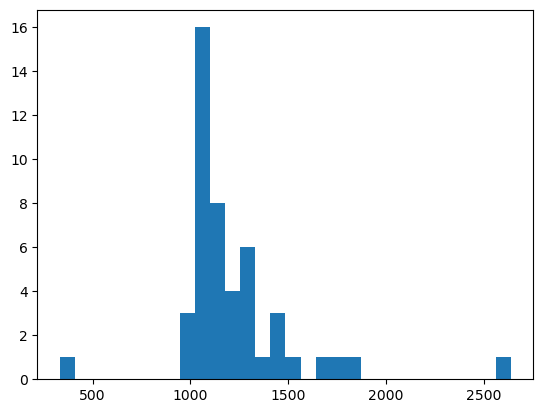

In [26]:
def plot_chunk_size_distribution(chunks, label=""):
    dist = {}
    for chunk in chunks:
        if type(chunk) is dict:
            length = chunk["char_len"]
        else:
            length = len(chunk)
        dist[length] = dist.get(length, 0) + 1
    plt.hist(dist, bins=30, label=label)

chunks = chunking_equal_size()
plot_chunk_size_distribution(chunks)

- uh oh, some variance in output, This may not be the best approach since the embedding could be 'stretched' or 'squished' containing too much or too little. As for the end result, it will always be a bit shorter. But as for the results too far out (max_size*2), they would perhaps have to be handled.

Lets also try to see if the other pdf extractors would be better since this seems to add titles to smaller texts that are not title.

In [ ]:
# TODOs: test other pdfs
# speed: pymupdf4llm
# quality: marker-pdf


import time
import pymupdf4llm  # pip install pymupdf4llm
# from marker.converters.pdf import PdfConverter  # pip install --user marker-pdf
# from marker.models import create_model_dict
# from marker.config.parser import ConfigParser

# pymupdf4llm
start = time.time()
md_pymupdf = pymupdf4llm.to_markdown(path)
# md_pymupdf = pymupdf4llm.to_text(path)
# md_pymupdf = pymupdf4llm.to_json(path)
t_pymupdf = time.time() - start

# # marker-pdf
# config_parser = ConfigParser({"output_format": "markdown"})
# converter = PdfConverter(
#     config=config_parser.generate_config_dict(),
#     artifact_dict=create_model_dict(),
# )

# start = time.time()
# # rendered = converter(path)
# # md_marker = rendered.markdown
# t_marker = time.time() - start

print(f"pymupdf4llm: {t_pymupdf:.2f}s, {len(md_pymupdf)} chars")
# print(f"marker-pdf:  {t_marker:.2f}s, {len(md_marker)} chars")

'\nimport time\nimport pymupdf4llm  # pip install pymupdf4llm\n# from marker.converters.pdf import PdfConverter  # pip install --user marker-pdf\n# from marker.models import create_model_dict\n# from marker.config.parser import ConfigParser\n\n# pymupdf4llm\nstart = time.time()\nmd_pymupdf = pymupdf4llm.to_markdown(path)\n# md_pymupdf = pymupdf4llm.to_text(path)\n# md_pymupdf = pymupdf4llm.to_json(path)\nt_pymupdf = time.time() - start\n\n# # marker-pdf\n# config_parser = ConfigParser({"output_format": "markdown"})\n# converter = PdfConverter(\n#     config=config_parser.generate_config_dict(),\n#     artifact_dict=create_model_dict(),\n# )\n\n# start = time.time()\n# # rendered = converter(path)\n# # md_marker = rendered.markdown\n# t_marker = time.time() - start\n\nprint(f"pymupdf4llm: {t_pymupdf:.2f}s, {len(md_pymupdf)} chars")\n# print(f"marker-pdf:  {t_marker:.2f}s, {len(md_marker)} chars")\n'

In [17]:
md_pymupdf

'_**NMR&D News**_ \n\n**Volume IV, Issue 12** \n\n## **Volume IV, Issue 12** \n\n## _**In this issue…**_ \n\nCO‟s Messages 2 Building Afghan Medical Capacity 3 USNS Mercy Pacific Partnership 4 DoD Bone Marrow Donor Program 5 ID Joint Planning Group 6 Capacity Building in Liberia 7 Kazakh Scientists Train at NMRC 8 Patient Condition Occurrence Tool 9 Combat Casualty Research Team 10 Accelerating Technology Transfer 11 NMRC Hosts Dining Out 12 Villasante Speaks at Notre Dame 13 Keane-Myers Speaks at Hopkins 14 Cub Scouts Learn Flag Etiquette 14 NMRC High School Outreach 15 NMRC Officers Teach Science 15 2012 Combined Federal Campaign 16 Ombudsman‟s Note 16 \n\n_**NMR&D News**_ is an authorized publication of the Naval Medical Research Center, 503 Robert Grant Avenue, Silver Spring, MD 20910. _NMR&D News_ is published monthly by the NMRC Public Affairs Office, 301-319-9378 or svc.pao.nmrc@med.navy.mil . \n\n_Commanding Officer_ Capt. John W. Sanders \n\n_Executive Officer_ Capt. Elizabeth

Lessons learnt: 
- marker-pdf, difficult installation, easily crashes on run, very slow runtime
- pymupdf4llm, very fasy but, doesnt capture, title vs text content
- unstructured, slow, good text grouping and reading

#### 6.2) Required System 1: Baseline RAG Pipeline 
2. Encode document content (use text at minimum)  

In [29]:
from transformers import CLIPModel, CLIPProcessor
from PIL import Image

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\kiran\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\kiran\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\kiran\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "c:\Users\kiran\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found

SystemError: initialization of _pywrap_checkpoint_reader raised unreported exception

In [28]:
def embed_img(path):
    image = Image.open(path)
    img_inputs = processor(images=image, return_tensors="pt")
    img_emb = model.get_image_features(**img_inputs)
    return img_emb

def embed_text(chunk):
    txt_inputs = processor(text=[chunk], return_tensors="pt", padding=True, truncation=True)
    txt_emb = model.get_text_features(**txt_inputs)    # [1, 512]
    return txt_emb

embedding = embed_text("Hi my name is Joe mama")

NameError: name 'processor' is not defined

In [ ]:
embedding.shape


torch.Size([1, 512])

#### Focusing on just finishing different chunking strategies

In [ ]:
class Chunking:
    HEADING_CATEGORIES = {"Title", "Header"}

    def __init__(self, blocks: List):
        self.blocks = blocks

    @staticmethod
    def _make_chunk(texts: List[str], extra_meta: Dict[str, Any] = None) -> Dict[str, Any]:
        """Helper function to store char_len which can be useful downstream"""
        chunk_text = " ".join(texts)
        chunk = {"text": chunk_text, "char_len": len(chunk_text)}
        if extra_meta:
            chunk.update(extra_meta)
        return chunk

    def fixed_size(self, max_chars: int = 1000) -> List[Dict[str, Any]]:
        """Concatenate blocks until max_chars is exceeded, then start a new chunk."""

        current_texts, chunks = [], []
        text_len, blocks_count = 0, len(self.blocks)
        for i, block in enumerate(self.blocks):
            text = block.text.strip()
            if not text:
                continue

            text_len += len(text)
            current_texts.append(text)
            if text_len > max_chars or i == blocks_count - 1:
                chunks.append(Chunking._make_chunk(current_texts))
                current_texts = []
                text_len = 0
        return chunks

    def sliding_window(
        self, window_charts: int = 1000, overlap_chars: int = 200
    ) -> List[Dict[str, Any]]:
        """
        Fixed-size windows with overlap so context at chunk boundaries
        is not lost. Good for dense text documents.
        """
        current_texts, chunks = [], []
        text_len, blocks_count = 0, len(self.blocks)
        for i, block in enumerate(self.blocks):
            text = block.text.strip()
            if not text:
                continue

            text_len += len(text)
            current_texts.append(text)
            if text_len > window_charts or i == blocks_count - 1:
                if chunks:
                    prev_text = chunks[-1]["text"][-overlap_chars:]  # use the actual text from the last chunk
                    current_texts = [prev_text] + current_texts
                else:
                    prev_text = ""
                
                current_texts.append(prev_text)
                chunks.append(Chunking._make_chunk(current_texts))
                current_texts = []
                text_len = overlap_chars
        
        return chunks

    def semantic(self) -> List[Dict[str, Any]]:
        """
        Group blocks into sections separated by title/header elements.
        Each heading starts a new chunk. This keeps the documents natural
        semantic boundaries intact.
        
        Consecutive headers without body text are merged forward so they
        attach to the next chunk that has actual content.
        """

        current_texts, chunks = [], []
        chunk_contains_text = False
        
        for block in self.blocks:
            text = block.text.strip()
            if not text:
                continue
            
            if block.category in self.HEADING_CATEGORIES:
                # Only flush if the current chunk has body text
                if chunk_contains_text:
                    chunks.append(Chunking._make_chunk(current_texts))
                    current_texts = []
                    chunk_contains_text = False
                
                current_texts.append(text)

            else:
                current_texts.append(text)
                chunk_contains_text = True
        
        # Add remaining - but if it's only headers, merge into the last chunk
        if current_texts:
            if chunk_contains_text or not chunks:
                chunks.append(Chunking._make_chunk(current_texts))
            else:
                # Trailing headers only - append to previous chunk
                prev = chunks[-1]
                combined = prev["text"] + " " + " ".join(current_texts)
                chunks[-1] = {"text": combined, "char_len": len(combined)}
        
        return chunks
    
    def hierarchical(self) -> List[Dict[str, Any]]:
        """
        Two-level hierarchy:
          - Level 1 (parent): full page text  (coarse retrieval)
          - Level 2 (child):  per-section text within each page  (fine retrieval)

        Returns a flat list but each chunk's metadata includes
        'level' ('page' or 'section') and 'page_number'.
        """
        # Group blocks by page number
        pages: dict[int, list] = {}
        for block in self.blocks:
            page = getattr(block.metadata, "page_number", None) or 0
            pages.setdefault(page, []).append(block)

        chunks: list[dict] = []

        for page_num in sorted(pages):
            page_blocks = pages[page_num]
            page_texts = [b.text.strip() for b in page_blocks if b.text.strip()]

            if not page_texts:
                continue

            # Parent chunk: whole page
            chunks.append(
                Chunking._make_chunk(
                    page_texts,
                    extra_meta={"level": "page", "page_number": page_num},
                )
            )

            # Child chunks: split by headings within the page
            section_texts: list[str] = []
            has_body = False
            for block in page_blocks:
                text = block.text.strip()
                if not text:
                    continue
                if block.category in self.HEADING_CATEGORIES:
                    if has_body and section_texts:
                        chunks.append(
                            Chunking._make_chunk(
                                section_texts,
                                extra_meta={"level": "section", "page_number": page_num},
                            )
                        )
                        section_texts = []
                        has_body = False
                    section_texts.append(text)
                else:
                    section_texts.append(text)
                    has_body = True

            if section_texts:
                if has_body or not chunks:
                    chunks.append(
                        Chunking._make_chunk(
                            section_texts,
                            extra_meta={"level": "section", "page_number": page_num},
                        )
                    )
                else:
                    # Trailing headers - merge into last section chunk for this page
                    prev = chunks[-1]
                    combined = prev["text"] + " " + " ".join(section_texts)
                    chunks[-1] = {**prev, "text": combined, "char_len": len(combined)}

        return chunks

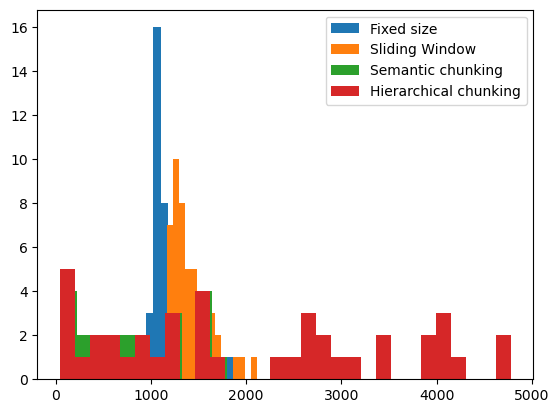

In [117]:

chunker = Chunking(blocks)

fixed_size_chunks = chunker.fixed_size()
sliding_size_chunks = chunker.sliding_window()
semantic_size_chunks = chunker.semantic()
hierarchical_size_chunks = chunker.hierarchical()
plot_chunk_size_distribution(fixed_size_chunks, label="Fixed size")
plot_chunk_size_distribution(sliding_size_chunks, label="Sliding Window")
plot_chunk_size_distribution(semantic_size_chunks, label="Semantic chunking")
plot_chunk_size_distribution(hierarchical_size_chunks, label="Hierarchical chunking")

plt.legend()

In [114]:
semantic_size_chunks[0:3]

[{'text': 'NMR&D News Volume IV, Issue 12 In this issue… 2 CO‟s Messages 3 Building Afghan Medical Capacity 4 USNS Mercy Pacific Partnership 5 DoD Bone Marrow Donor Program 6 ID Joint Planning Group 7 Capacity Building in Liberia 8 Kazakh Scientists Train at NMRC 9 Patient Condition Occurrence Tool 10 Combat Casualty Research Team 11 Accelerating Technology Transfer 12 NMRC Hosts Dining Out 13 Villasante Speaks at Notre Dame 14 Keane-Myers Speaks at Hopkins 14 Cub Scouts Learn Flag Etiquette 15 NMRC High School Outreach NMRC Officers Teach Science 15 2012 Combined Federal Campaign 16 16 Ombudsman‟s Note NMR&D News is an authorized publica- tion of the Naval Medical Research Center, 503 Robert Grant Avenue, Silver Spring, MD 20910. NMR&D News is published monthly by the NMRC Public Affairs Office, 301-319-9378 or svc.pao.nmrc@med.navy.mil . Commanding Officer Capt. John W. Sanders',
  'char_len': 881},
 {'text': 'Executive Officer Capt. Elizabeth Montcalm-Smith Director for Administrati

In [115]:
hierarchical_size_chunks

[{'text': 'NMR&D News Volume IV, Issue 12 In this issue… 2 CO‟s Messages 3 Building Afghan Medical Capacity 4 USNS Mercy Pacific Partnership 5 DoD Bone Marrow Donor Program 6 ID Joint Planning Group 7 Capacity Building in Liberia 8 Kazakh Scientists Train at NMRC 9 Patient Condition Occurrence Tool 10 Combat Casualty Research Team 11 Accelerating Technology Transfer 12 NMRC Hosts Dining Out 13 Villasante Speaks at Notre Dame 14 Keane-Myers Speaks at Hopkins 14 Cub Scouts Learn Flag Etiquette 15 NMRC High School Outreach NMRC Officers Teach Science 15 2012 Combined Federal Campaign 16 16 Ombudsman‟s Note NMR&D News is an authorized publica- tion of the Naval Medical Research Center, 503 Robert Grant Avenue, Silver Spring, MD 20910. NMR&D News is published monthly by the NMRC Public Affairs Office, 301-319-9378 or svc.pao.nmrc@med.navy.mil . Commanding Officer Capt. John W. Sanders Executive Officer Capt. Elizabeth Montcalm-Smith Director for Administration Lt. Cmdr. Nathaniel Smith Publ

In [ ]:
# src/data/pdf_processor_unstructured.py
# Alternative PDF processor using unstructured library

from pathlib import Path
from typing import Dict, List, Any
import logging
from unstructured.partition.auto import partition

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


def extract_text_from_pdf(pdf_path: Path) -> Dict[str, Any]:
    """
    Extract text from a PDF file using unstructured library.
    Returns dict with pdf_name, full_text, and page_texts.
    """
    result = {
        "pdf_name": pdf_path.name,
        "pdf_path": str(pdf_path),
        "full_text": "",
        "pages": [],  # List of {page_num, text}
    }

    try:
        # Use unstructured to partition the PDF into semantic blocks
        blocks = partition(filename=str(pdf_path))

        # Group blocks by page (if page info is available)
        current_page = 1
        page_text = []

        for block in blocks:
            text = block.text.strip()
            if not text:
                continue

            # Try to get page number from metadata
            page_num = (
                getattr(block.metadata, "page_number", None)
                if hasattr(block, "metadata")
                else None
            )

            if page_num and page_num != current_page:
                # Save previous page
                if page_text:
                    result["pages"].append(
                        {"page_num": current_page, "text": " ".join(page_text)}
                    )
                    page_text = []

                current_page = page_num

            page_text.append(text)
            result["full_text"] += text + " "

        # Add last page
        if page_text:
            result["pages"].append(
                {"page_num": current_page, "text": " ".join(page_text)}
            )

        # If no page info available, treat as single page
        if not result["pages"] and result["full_text"]:
            result["pages"].append({"page_num": 1, "text": result["full_text"]})

    except Exception as e:
        logger.error(f"Error processing {pdf_path}: {e}")

    return result


def process_all_pdfs(pdf_dir: Path) -> List[Dict[str, Any]]:
    """Process all PDFs in a directory using unstructured."""
    pdf_files = list(pdf_dir.glob("*.pdf"))
    logger.info(f"Found {len(pdf_files)} PDF files")

    all_documents = []

    for i, pdf_path in enumerate(pdf_files):
        if i % 10 == 0:
            logger.info(f"Processing PDF {i + 1}/{len(pdf_files)}")

        doc = extract_text_from_pdf(pdf_path)

        # Only add if text was extracted
        if doc["full_text"].strip():
            all_documents.append(doc)

    logger.info(f"Successfully processed {len(all_documents)} PDFs")
    return all_documents
